# Demo: Agentic Real-Time Metadata Standardization

## Configurations

`DATA_ROOT` points to the root data directory. The evaluation functions expect the following directory structure underneath it:

```
DATA_ROOT/
├── schemas/
│   ├── atacseq.json              # JSON Schema for each assay type
│   ├── lcms.json
│   └── ...
├── atacseq/                      # One directory per assay type
│   ├── input/
│   │   ├── atacseq-<hash>.json   # Legacy metadata records (input)
│   │   └── ...
│   ├── gold/
│   │   ├── atacseq-<hash>.json   # Gold-standard reference outputs
│   │   └── ...
│   └── output/
│       └── <MODEL>/              # e.g., "gpt5mini"
│           ├── baseline/
│           │   ├── atacseq-<hash>.json   # Prompt-only LLM outputs
│           │   └── ...
│           └── experiment/
│               ├── atacseq-<hash>.json   # Tool-augmented agent outputs
│               └── ...
├── lcms/
│   ├── input/ ...
│   ├── gold/ ...
│   └── output/ ...
└── ...
```

Gold-standard and output files share the same filenames so that each output can be matched to its reference for evaluation.

In [18]:
DATA_ROOT = "../data"

`MODEL` specifies which LLM model was used for the migration run (e.g., `"gpt5mini"`).

In [19]:
MODEL = "gpt5mini"

`RUN_TYPE` selects which output set to evaluate — either `"baseline"` (prompt-only LLM) or `"experiment"` (tool-augmented agent). This determines which subdirectory under each assay is used when loading output files for comparison against the gold standard.

In [20]:
RUN_TYPE = "experiment"

## Run Evaluations

Run the standardization agent on every assay type. The loop calls `run_experiment` once per assay, reading inputs from `DATA_ROOT/<assay>/input` and writing outputs to `DATA_ROOT/<assay>/output/<MODEL>/<RUN_TYPE>`.

In [21]:
RUN_EVALUATION = False  # Change to True to run the evaluation. Be carefule this operation can be costly!

In [22]:
# To run a single assay from the command line instead of bulk evaluation:
# uv run python -m evaluation \
#     --input "data/atacseq/input" \
#     --target-schema "https://repo.metadatacenter.org/templates/dd5e8653-81cf-470b-b71b-15cab421bb84" \
#     --output "data/atacseq/output/gpt5mini/experiment" \
#     --model "gpt-5-mini" \
#     --concurrent 8 \
#     --experiment

if RUN_EVALUATION:
    from functools import partial
    from pathlib import Path

    from assays import ASSAY_SCHEMAS
    from evaluate import run_experiment

    if MODEL == "gpt41mini":
        gpt_model = "gpt-4.1-mini"
    elif MODEL == "gpt5mini":
        gpt_model = "gpt-5-mini"
    elif MODEL == "gpt5":
        gpt_model = "gpt-5"
    else:
        raise ValueError(f"Unknown model name: {MODEL}")

    if RUN_TYPE == "baseline":
        from baseline import build_baseline_workflow as build_workflow, build_user_prompt
    else:
        from experiment import build_experiment_workflow as build_workflow, build_user_prompt

    workflow_factory = partial(build_workflow, model=gpt_model)

    for assay, schema_iri in ASSAY_SCHEMAS.items():
        print(f"Running {RUN_TYPE} for {assay}...")
        run_experiment(
            template_iri=schema_iri,
            input_dir=Path(DATA_ROOT) / assay / "input",
            output_dir=Path(DATA_ROOT) / assay / "output" / MODEL / RUN_TYPE,
            workflow_factory=workflow_factory,
            user_prompt_builder=build_user_prompt,
            max_concurrency=8,
        )
else:
    print("Skipping evaluation runs.")

Skipping evaluation runs.


## Data Analysis

### 1. Per-Assay Accuracy Summary

`create_per_assay_accuracy_summary` iterates over all assay directories, calls `apply_metrics` on each gold-standard/output file pair within an assay, and averages the results to produce a mean accuracy per assay. The returned DataFrame contains three metric columns:

- **ontology_constrained_field_accuracy** — accuracy on fields whose values must come from a controlled ontology.
- **non_ontology_constrained_field_accuracy** — accuracy on free-text or non-ontology fields.
- **all_field_accuracy** — combined accuracy across all fields.

In [23]:
from data_analysis import create_per_assay_accuracy_summary

per_assay_df = create_per_assay_accuracy_summary(DATA_ROOT, MODEL, RUN_TYPE)
per_assay_df

,assay,ontology_constrained_field_accuracy,non_ontology_constrained_field_accuracy,all_field_accuracy
0,ATACseq,0.80,0.85,0.83
1,RNAseq,0.75,0.80,0.78
2,Auto-fluorescence,0.88,0.84,0.85
3,Cell DIVE,0.88,0.78,0.80
4,CODEX,0.82,0.77,0.79
5,Histology,0.76,0.76,0.76
6,IMC-2D,0.91,0.70,0.77
7,Lightsheet,1.00,0.79,0.86
8,MIBI,1.00,0.78,0.85
9,DESI,0.55,0.73,0.64


### 2. Overall Accuracy Summary

`create_overall_accuracy_summary` computes aggregate accuracy from raw counts rather than averaging ratios. It accumulates the number of correct and total fields across every gold-standard/output file pair from all assays, then divides once at the end to produce a single accuracy value. This avoids the bias that can arise from averaging per-file or per-assay ratios when sample sizes differ.

In [24]:
from data_analysis import create_overall_accuracy_summary

overall_df = create_overall_accuracy_summary(DATA_ROOT, MODEL, RUN_TYPE)
overall_df

,ontology_constrained_accuracy,non_ontology_constrained_accuracy,all_field_accuracy
0,0.78,0.79,0.79


## Plots

In [25]:
from plots import plot_grouped_bar_chart

`plot_grouped_bar_chart` produces a side-by-side bar chart comparing **baseline** vs **experiment** accuracy for a chosen metric across all assay types. Available metrics for the `metric` parameter:

- `ontology_constrained_field_accuracy`
- `non_ontology_constrained_field_accuracy`
- `all_field_accuracy`

Set `show_error_bars=True` to display min/max error bars on each bar, showing the range of accuracy values within each assay.

### Ontology-Constrained Field Accuracy 

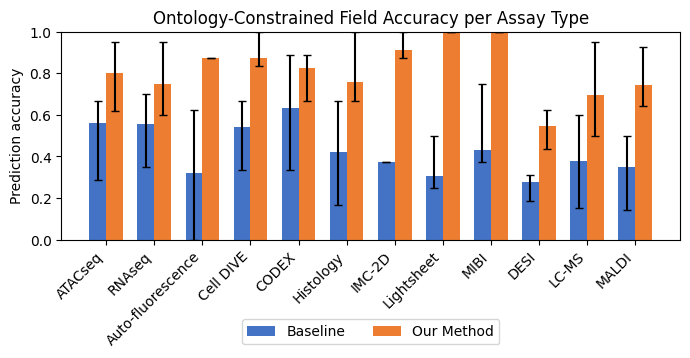

In [26]:
plot_grouped_bar_chart(
    DATA_ROOT,
    MODEL,
    metric="ontology_constrained_field_accuracy",
    title="Ontology-Constrained Field Accuracy per Assay Type",
)

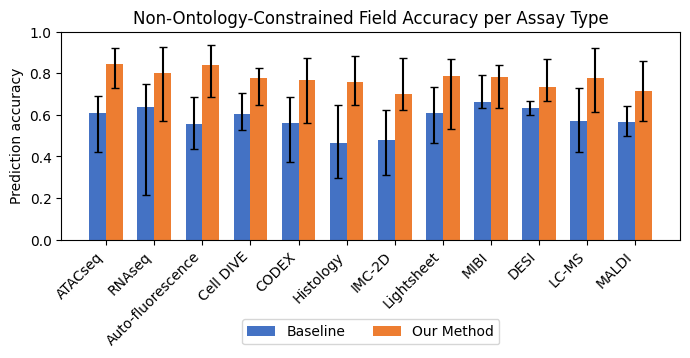

In [27]:
plot_grouped_bar_chart(
    DATA_ROOT,
    MODEL,
    metric="non_ontology_constrained_field_accuracy",
    title="Non-Ontology-Constrained Field Accuracy per Assay Type",
)

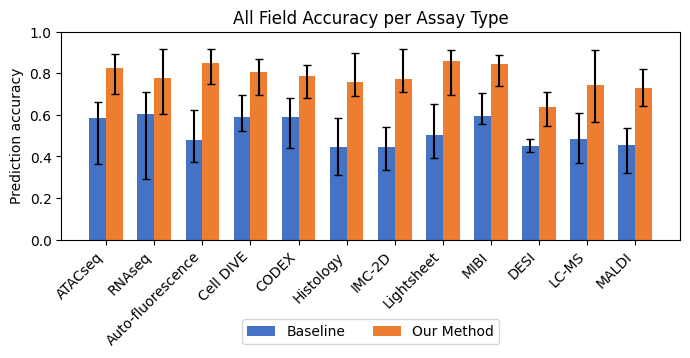

In [28]:
plot_grouped_bar_chart(
    DATA_ROOT,
    MODEL,
    metric="all_field_accuracy",
    title="All Field Accuracy per Assay Type",
)

## Error Analysis

`create_error_report` aggregates field-level prediction errors into a summary report. It compares each output file against its gold standard, identifies every field where the predicted value differs from the expected value, and groups identical error patterns together. The returned DataFrame contains the following columns:

- **error_type** — the category of mismatch (e.g., wrong value, missing value).
- **field_type** — whether the field is ontology-constrained or non-ontology-constrained.
- **expected_value** — the field name and its gold-standard value.
- **predicted_value** — the field name and the value produced by the model.
- **frequency** — how many times this exact error pattern occurred across all samples.
- **assays** — which assay types exhibited this error.

In [29]:
from data_analysis import create_error_report

error_report_df = create_error_report(DATA_ROOT, MODEL, RUN_TYPE)
error_report_df

,error_type,field_type,expected_value,predicted_value,frequency,assays
0,wrong_value,ontology-constrained,analyte_class: Lipid,analyte_class: lipids,125,"desi, lcms, maldi"
1,delimiter_or_case,ontology-constrained,acquisition_instrument_model: Axio Scan.Z1,acquisition_instrument_model: AxioScan.Z1,114,"af, histology"
2,wrong_value,ontology-constrained,acquisition_instrument_model: NovaSeq 6000,acquisition_instrument_model: NovaSeq,102,"atacseq, rnaseq"
3,type_mismatch,non-ontology-constrained,roi_id: 1,roi_id: 1,100,mibi
4,wrong_value,ontology-constrained,preparation_instrument_vendor: Akoya Biosciences,preparation_instrument_vendor: CODEX,99,codex
...,...,...,...,...,...,...
350,value_mismatch,non-ontology-constrained,number_of_input_cells_or_nuclei: 5691,number_of_input_cells_or_nuclei: 880000,1,atacseq
351,value_mismatch,non-ontology-constrained,number_of_input_cells_or_nuclei: 6000,number_of_input_cells_or_nuclei: 1580000,1,atacseq
352,value_mismatch,non-ontology-constrained,number_of_input_cells_or_nuclei: 6167,number_of_input_cells_or_nuclei: 700000,1,atacseq
353,value_mismatch,non-ontology-constrained,number_of_input_cells_or_nuclei: 6500,number_of_input_cells_or_nuclei: 10600000,1,atacseq
